### 🧠 Answer Synthesis from Multiple Sources
✅ What Is It?

Answer synthesis from multiple sources is the process where an AI agent collects information from different retrieval tools or knowledge bases, and merges that information into a single, coherent, and contextually rich answer.

This is a core capability in Agentic RAG, where the system is more than just a simple retriever — it plans, retrieves, and then synthesizes an answer that draws from multiple sources.



🎯 Why It’s Needed
Most real-world queries are:
- Multifaceted (require multiple types of information)
- Ambiguous or incomplete (need refinement)
- Open-ended (don’t map to a single document or source)

🔍 This makes retrieving from a single vector DB insufficient.

Instead, we want an agent that can:

- Decide what to fetch from where (retrieval planning)
- Retrieve content from multiple tools (e.g., Wikipedia, PDFs, APIs, SQL)
- Evaluate and merge that context
- Produce a single human-like response

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders.youtube import YoutubeLoader
from langchain_community.document_loaders import ArxivLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import wikipediaapi
import arxiv
from langgraph.graph import StateGraph, END

d:\Github_Codes\Ultimate RAG Bootcamp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\harsh\AppData\Local\Temp\ipykernel_31856\3751473337.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [2]:
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=init_chat_model("groq:llama-3.3-70b-versatile")

In [3]:
def load_text_retriever(file_path):
    docs = TextLoader(file_path, encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = splitter.split_documents(docs)
    vs = FAISS.from_documents(chunks, OllamaEmbeddings(model="nomic-embed-text"))
    return vs.as_retriever()

def load_youtube_retriever():
    # Mocked YouTube transcript text
    content = """
    This video explains how agentic AI systems rely on feedback loops, memory, and tool use.
    It compares them to traditional pipeline-based LLMs. Temporal reasoning and autonomous tasking are emphasized.
    """
    doc = Document(page_content=content, metadata={"source": "youtube"})
    vectorstore = FAISS.from_documents([doc], OllamaEmbeddings(model="nomic-embed-text"))
    return vectorstore.as_retriever()


def wikipedia_search(query: str) -> str:
    print("🌐 Searching Wikipedia...")
    wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent="ultimate-rag-agent/1.0"
    )
    page = wiki.page(query)
    
    if not page.exists():
        return "Wikipedia page not found."

    return page.summary[:4000]
        

def arxiv_search(query: str) -> str:
    """Search recent ArXiv papers."""
    print("📄 Searching ArXiv...")
    client = arxiv.Client()
    
    search = arxiv.Search(
        query=query,
        max_results=2
    )

    papers = client.results(search)

    return "\n\n".join(
        f"Title: {p.title}\n\n{p.summary[:1000]}"
        for p in papers
    )

In [4]:
text_retriever = load_text_retriever("research_notes.txt")
youtube_retriever = load_youtube_retriever()

In [5]:
### state
class MultiSourceRAGState(BaseModel):
    question: str
    text_docs: List[Document] = []
    yt_docs: List[Document] = []
    wiki_context: str = ""
    arxiv_context: str = ""
    final_answer: str = ""

In [6]:
### Retrieval Nodes
def retrieve_text(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = text_retriever.invoke(state.question)
    return state.model_copy(update={"text_docs": docs})

def retrieve_yt(state: MultiSourceRAGState) -> MultiSourceRAGState:
    docs = youtube_retriever.invoke(state.question)
    return state.model_copy(update={"yt_docs": docs})

def retrieve_wikipedia(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = wikipedia_search(state.question)
    return state.model_copy(update={"wiki_context": result})

def retrieve_arxiv(state: MultiSourceRAGState) -> MultiSourceRAGState:
    result = arxiv_search(state.question)
    return state.model_copy(update={"arxiv_context": result})

In [7]:
## synthesize
def synthesize_answer(state: MultiSourceRAGState) -> MultiSourceRAGState:
    
    context = ""

    context += "\n\n[Internal Docs]\n" + "\n".join([doc.page_content for doc in state.text_docs])
    context += "\n\n[YouTube Transcript]\n" + "\n".join([doc.page_content for doc in state.yt_docs])
    context += "\n\n[Wikipedia]\n" + state.wiki_context
    context += "\n\n[ArXiv]\n" + state.arxiv_context

    prompt = f"""You have retrieved relevant context from multiple sources. Now synthesize a complete and coherent answer.

Question: {state.question}

Context:
{context}

Final Answer:"""

    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"final_answer": answer})

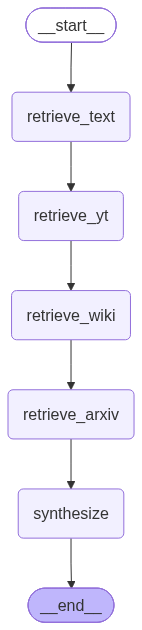

In [8]:
builder = StateGraph(MultiSourceRAGState)

builder.add_node("retrieve_text", retrieve_text)
builder.add_node("retrieve_yt", retrieve_yt)
builder.add_node("retrieve_wiki", retrieve_wikipedia)
builder.add_node("retrieve_arxiv", retrieve_arxiv)
builder.add_node("synthesize", synthesize_answer)

builder.set_entry_point("retrieve_text")
builder.add_edge("retrieve_text", "retrieve_yt")
builder.add_edge("retrieve_yt", "retrieve_wiki")
builder.add_edge("retrieve_wiki", "retrieve_arxiv")
builder.add_edge("retrieve_arxiv", "synthesize")
builder.add_edge("synthesize", END)

graph = builder.compile()
graph

In [9]:
question = "What are transformer agents and how are they evolving in recent research?"
state = MultiSourceRAGState(question=question)
result = graph.invoke(state)

print("✅ Final Answer:\n")
print(result["final_answer"])


🌐 Searching Wikipedia...
📄 Searching ArXiv...
✅ Final Answer:

Transformer agents refer to a class of artificial intelligence (AI) systems that utilize transformer-based architectures to enable autonomous tasking, temporal reasoning, and dynamic adaptation. These agents are designed to learn from feedback loops, leverage memory, and employ tool use to improve their performance over time. Recent research has focused on developing self-evolving transformer agents that can automatically enhance their capabilities based on interaction data and environmental feedback.

The evolution of transformer agents is driven by advances in large language models (LLMs) and the need for more adaptable and autonomous AI systems. Current research explores techniques such as sparse attention models, dynamic retrieval-agent reasoning, and tool-augmented prompting to improve the efficiency and effectiveness of transformer agents.

Some notable developments in transformer agent research include:

1. **Efficie

In [10]:
result

{'question': 'What are transformer agents and how are they evolving in recent research?',
 'text_docs': [Document(id='43b31e45-05fa-4f0c-a97d-9e4727c6a8e5', metadata={'source': 'research_notes.txt'}, page_content='Experiment Log: Transformer Evaluation - July 2024\n\nEfficientFormer:\n- Top-1 accuracy: 92.4% on TinyImageNet\n- Peak memory usage: 290MB (batch size = 16)\n- Deployment target: Raspberry Pi 4\n- Notes: Works well in quantized int8 mode with no major accuracy drop\n\nLongformer:\n- Evaluation on customer support logs (max tokens: 8192)\n- Latency >1.2s per query in streaming setting\n- Observations: Chunk-based hybrid attention may reduce delay'),
  Document(id='3e4332e7-5e4c-41ee-9e58-9bcef68cd76d', metadata={'source': 'research_notes.txt'}, page_content='7. Safety:\n   - Toxicity detection via Detoxify\n   - Out-of-scope filter via zero-shot classifier\n   - Red teaming involved adversarial prompt testing\n\nConclusion:\n\n- LLaMA2 continues to be promising for controlled